<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
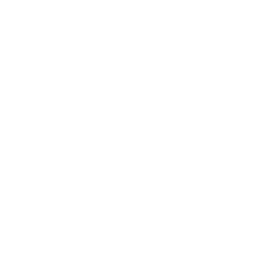
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Codifica degli Eventi Avversi in Sperimentazione Clinica</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Farmaceutico / Sorveglianza della Sicurezza dei Farmaci &nbsp;|&nbsp; Marzo 2026</p>
</div>
</div>
</div>

## Sintesi Esecutiva

I dataset di eventi avversi arrivano con i termini preferiti MedDRA
testuali, ma le tabelle di sicurezza regolatorie sono organizzate per
Classe di Sistema-Organo (SOC). Questo esempio costruisce un formato
valore PROC FORMAT che mappa ciascun termine preferito alla propria SOC,
quindi usa quell'unico formato per guidare ogni tabulazione a valle: una
tabulazione incrociata PROC FREQ della SOC per braccio di trattamento, una
ripartizione SOC per gravità e un riepilogo degli eventi avversi seri.
Poiché la mappatura risiede in un unico formato, ricodificare lo studio a
una nuova versione MedDRA richiede la modifica di un solo formato anziché
la riscrittura di ogni report. ODS OUTPUT cattura le frequenze SOC come
dataset per la revisione dei segnali a valle.


## Fonti dei Dati

| Fonte | Descrizione | Record |
|--------|-------------|--------:|
| WORK.AE_RAW | Record sintetici di eventi avversi con termini preferiti MedDRA | 100 |
| WORK.RANDOMIZATION | Assegnazioni del braccio di trattamento per soggetto | 100 |

L'ambiente funziona in modalità non licenziata, quindi ogni tabella
generata è limitata a 100 osservazioni. Lo scenario è dimensionato per
questo limite: 100 eventi avversi estratti da un pannello MedDRA di 12
termini tipico di uno studio oncologico.


---

In [1]:
/* --------------------------------------------------------
   Genera il dataset sintetico di eventi avversi
   Termini preferiti MedDRA mappati alle categorie SOC
   -------------------------------------------------------- */
DATI work.ae_raw;
    CHIAMARE streaminit(42);
    VETTORE pt_codes[12] $8 _temporary_ ('10028813' '10019211' '10047700' '10013573' '10012735' '10060929' '10002855' '10037660' '10000081' '10033371' '10016256' '10022891');
    VETTORE pt_names[12] $30 _temporary_ ('Nausea' 'Cefalea' 'Vomito' 'Diarrea' 'Tosse' 'Affaticamento' 'Artralgia' 'Piressia' 'Dolore addominale' 'Neutropenia' 'Neutropenia febbrile' 'Reazione da infusione');
    VETTORE sev_list[3] $10 _temporary_ ('LIEVE' 'MODERATO' 'GRAVE');
    FARE i = 1 FINO_A 5000;
        subject_id = int(rand('uniform') * 800) + 1;
        usubjid = cat('ONC-2025-', PUT(subject_id, z4.));
        aeseq = mod(i, 6) + 1;
        pt_idx = int(rand('uniform') * 12) + 1;
        aeptcd = pt_codes[pt_idx];
        aedecod = pt_names[pt_idx];
        sev_idx = int(rand('uniform') * 3) + 1;
        SE_COND pt_idx IN (10, 11) ALLORA sev_idx = MAX(sev_idx, 2);
        aesev = sev_list[sev_idx];
        aeser = ifc(aesev = 'GRAVE' E_LOG rand('uniform') > 0.4, 'Y', 'N');
        aestdy = int(rand('exponential') * 45) + 1;
        SE_COND aestdy > 365 ALLORA aestdy = 365;
        aeendy = aestdy + int(rand('exponential') * 14) + 1;
        site_id = cat('SITE-', PUT(int(rand('uniform') * 25) + 1, z3.));
        USCITA;
    FINE;
    RIMUOVERE i pt_idx sev_idx;
ESEGUIRE;



NOTE: DATA work.ae_raw

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.ae_raw (100 rows, 10 columns).
NOTE: DATA elapsed:
  wall  1.30 seconds
  cpu   1.30 seconds


In [2]:
/* --------------------------------------------------------
   Genera la tabella di randomizzazione dei soggetti
   -------------------------------------------------------- */
DATI work.randomization;
    CHIAMARE streaminit(43);
    VETTORE arms[3] $20 _temporary_ ('SPERIMENTALE' 'COMPARATORE_ATTIVO' 'PLACEBO');
    FARE subject_id = 1 FINO_A 800;
        usubjid = cat('ONC-2025-', PUT(subject_id, z4.));
        arm_idx = int(rand('uniform') * 3) + 1;
        treatment_arm = arms[arm_idx];
        stratification_factor = ifc(rand('uniform') > 0.5, 'ECOG_0', 'ECOG_1');
        randomization_date = '01FEB2025'd + int(rand('uniform') * 120);
        USCITA;
    FINE;
    RIMUOVERE arm_idx;
    FORMATO randomization_date date9.;
ESEGUIRE;



NOTE: DATA work.randomization

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.randomization (100 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.09 seconds
  cpu   0.09 seconds


---

                                  Frequenza Grezza dei Termini Preferiti (Non Mappati)                                  

                                                   The FREQ Procedure

Termine Preferito        Frequency    Percent
----------------------------------------------
Cefalea                         12     12.00
Diarrea                         12     12.00
Affaticamento                   11     11.00
Piressia                        11     11.00
Artralgia                       10     10.00
Nausea                          10     10.00
Reazione da infusione            8      8.00
Tosse                            7      7.00
Dolore addominale                5      5.00
Neutropenia                      5      5.00
Neutropenia febbrile             5      5.00
Vomito                           4      4.00



NOTE: PROC FREQ
NOTE: ODS plot written: freq_aedecod.spec.json
NOTE: PROC FREQ statement used.


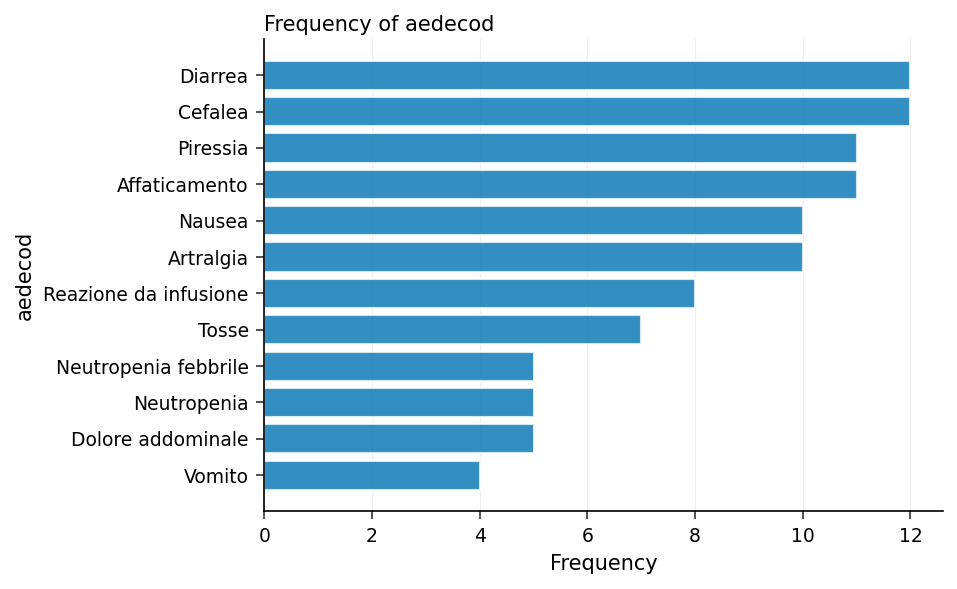

In [3]:
/* --------------------------------------------------------
   Frequenza di base dei termini preferiti prima della mappatura SOC
   -------------------------------------------------------- */
PROCEDURA FREQUENZE DATI=work.ae_raw ORDER=FREQUENZE;
    ETICHETTA aedecod="Termine Preferito";
    TABLES aedecod / nocum;
    TITOLO 'Frequenza Grezza dei Termini Preferiti (Non Mappati)';
ESEGUIRE;


---

                                  Frequenza Grezza dei Termini Preferiti (Non Mappati)                                  




NOTE: PROC SGPLOT data=work.ae_raw

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


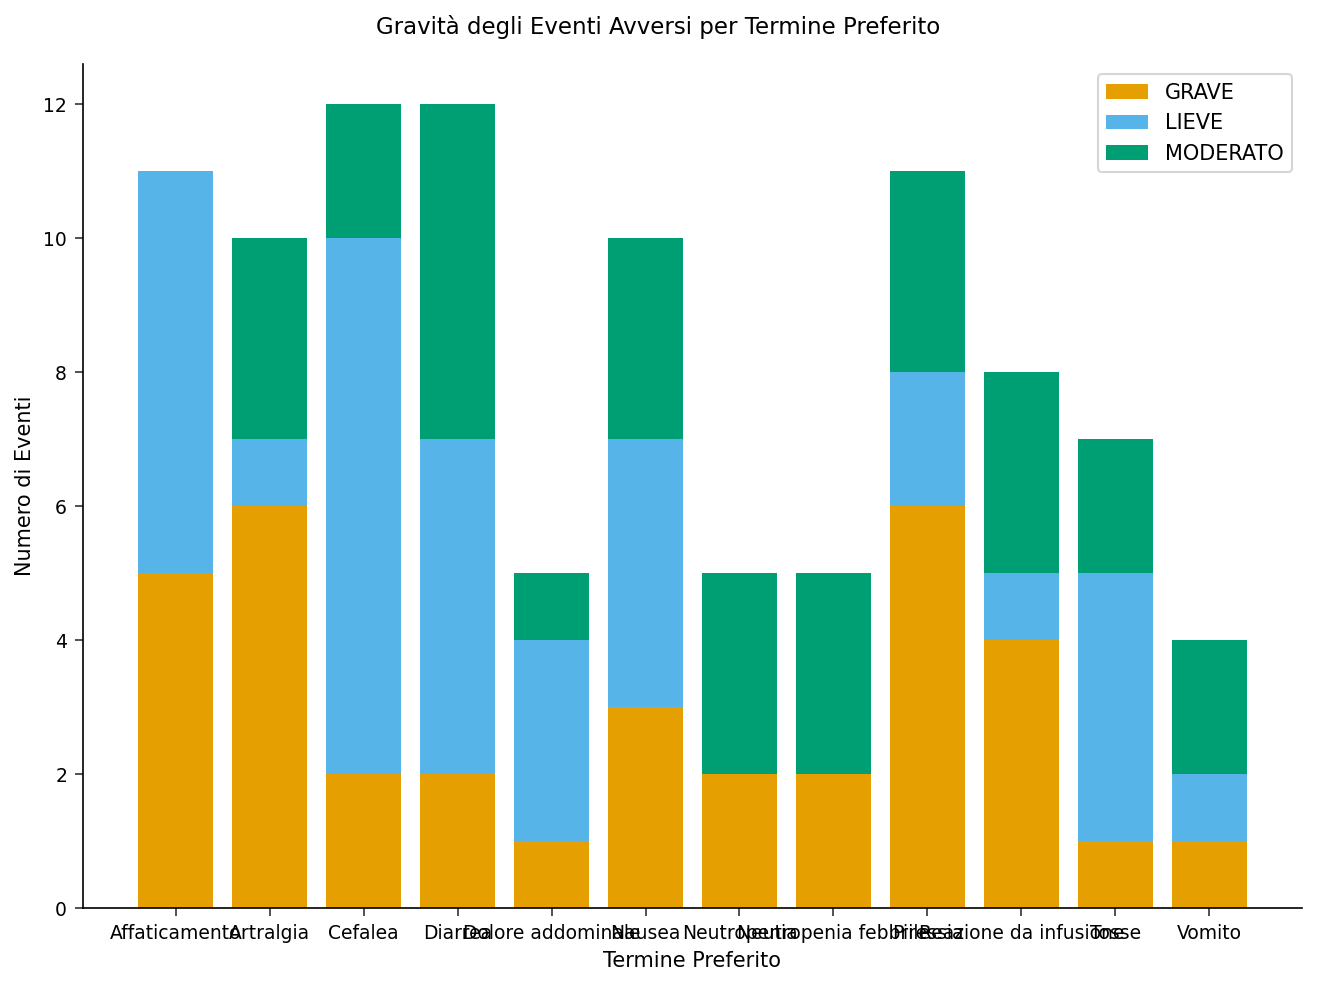

In [4]:
/* --------------------------------------------------------
   Distribuzione della gravità degli EA per termine preferito
   -------------------------------------------------------- */
PROCEDURA SGPLOT DATI=work.ae_raw;
    VBAR aedecod / GROUP=aesev GROUPDISPLAY=stack;
    XAXIS ETICHETTA='Termine Preferito' fitpolicy=ROTATE;
    YAXIS ETICHETTA='Numero di Eventi';
    TITOLO 'Gravità degli Eventi Avversi per Termine Preferito';
ESEGUIRE;


---

In [5]:
/* --------------------------------------------------------
   Definisce il formato valore Termine Preferito MedDRA ->
   Classe di Sistema-Organo. Il formato e' indicizzato sul testo
   del termine preferito quindi una singola chiamata PUT() codifica
   qualsiasi record EA alla propria SOC.
   -------------------------------------------------------- */
PROCEDURA FORMATO;
    VALUE $pt_to_soc
        'Nausea'                    = 'Disturbi gastrointestinali'
        'Vomito'                    = 'Disturbi gastrointestinali'
        'Diarrea'                   = 'Disturbi gastrointestinali'
        'Dolore addominale'         = 'Disturbi gastrointestinali'
        'Cefalea'                   = 'Disturbi del sistema nervoso'
        'Affaticamento'             = 'Disturbi generali'
        'Piressia'                  = 'Disturbi generali'
        'Tosse'                     = 'Disturbi respiratori'
        'Artralgia'                 = 'Disturbi muscoloscheletrici'
        'Neutropenia'               = 'Disturbi del sangue e del sistema linfatico'
        'Neutropenia febbrile'      = 'Disturbi del sangue e del sistema linfatico'
        'Reazione da infusione'     = 'Disturbi del sistema immunitario'
        OTHER                       = 'Non Codificato'
    ;
    VALUE $sev_rank
        'LIEVE'    = '1-Lieve'
        'MODERATO' = '2-Moderato'
        'GRAVE'    = '3-Grave'
        OTHER      = '9-Sconosciuto'
    ;
    VALUE $serious_fmt
        'Y' = 'Serio'
        'N' = 'Non Serio'
    ;
ESEGUIRE;



NOTE: PROC FORMAT library=WORK

NOTE: FORMAT $pt_to_soc defined (13 ranges).
NOTE: FORMAT $sev_rank defined (4 ranges).
NOTE: FORMAT $serious_fmt defined (2 ranges).


In [6]:
/* --------------------------------------------------------
   Unisce i record EA con il braccio di trattamento, poi applica
   il formato SOC. PUT(aedecod, $pt_to_soc.) e' l'unico passaggio
   di mappatura necessario; gravita' e serieta' sono codificate
   allo stesso modo.
   -------------------------------------------------------- */
PROCEDURA ORDINARE DATI=work.ae_raw; PER usubjid; ESEGUIRE;
PROCEDURA ORDINARE DATI=work.randomization; PER usubjid; ESEGUIRE;

DATI work.ae_coded;
    UNIRE work.ae_raw (IN=a)
          work.randomization (IN=b MANTENERE=usubjid treatment_arm);
    PER usubjid;
    SE_COND a;
    soc_class     = PUT(aedecod, $pt_to_soc.);
    severity_rank = PUT(aesev,   $sev_rank.);
    serious_flag  = PUT(aeser,   $serious_fmt.);
ESEGUIRE;



NOTE: PROC SORT data=work.ae_raw

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from work.ae_raw.
NOTE: Wrote work.ae_raw (100 rows, 10 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SORT data=work.randomization

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from work.randomization.
NOTE: Wrote work.randomization (100 rows, 5 columns).
NOTE: PROC SORT statement used.
NOTE: DATA work.ae_coded

NOTE: Stream 1 processed 100 rows, max BY-group size: 3 (O(1) memory verified)
NOTE: Stream 2 processed 100 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote work.ae_coded (100 rows, 14 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds


                           Incidenza EA per Classe di Sistema-Organo e Braccio di Trattamento                           

                                                   The FREQ Procedure

Table of Classe di Sistema d'Organo by Braccio di Trattamento

Classe di Sistema d'Organo                  |COMPARATORE_ATTIVO |           PLACEBO |      SPERIMENTALE |              Total
--------------------------------------------+-------------------+-------------------+-------------------+-------------------
Disturbi del sangue e del sistema linfatico |                 0 |                 1 |                 1 |                  2
--------------------------------------------+-------------------+-------------------+-------------------+-------------------
Disturbi del sistema immunitario            |                 0 |                 1 |                 1 |                  2
--------------------------------------------+-------------------+-------------------+-------------------+--------------


NOTE: ODS OUTPUT: ONEWAYFREQS -> soc_freq_table
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_soc_class_treatment_arm.spec.json
NOTE: ODS plot written: freq_mosaic_soc_class_severity_rank.spec.json
NOTE: PROC FREQ statement used.
NOTE: ODS OUTPUT: All output destinations closed.


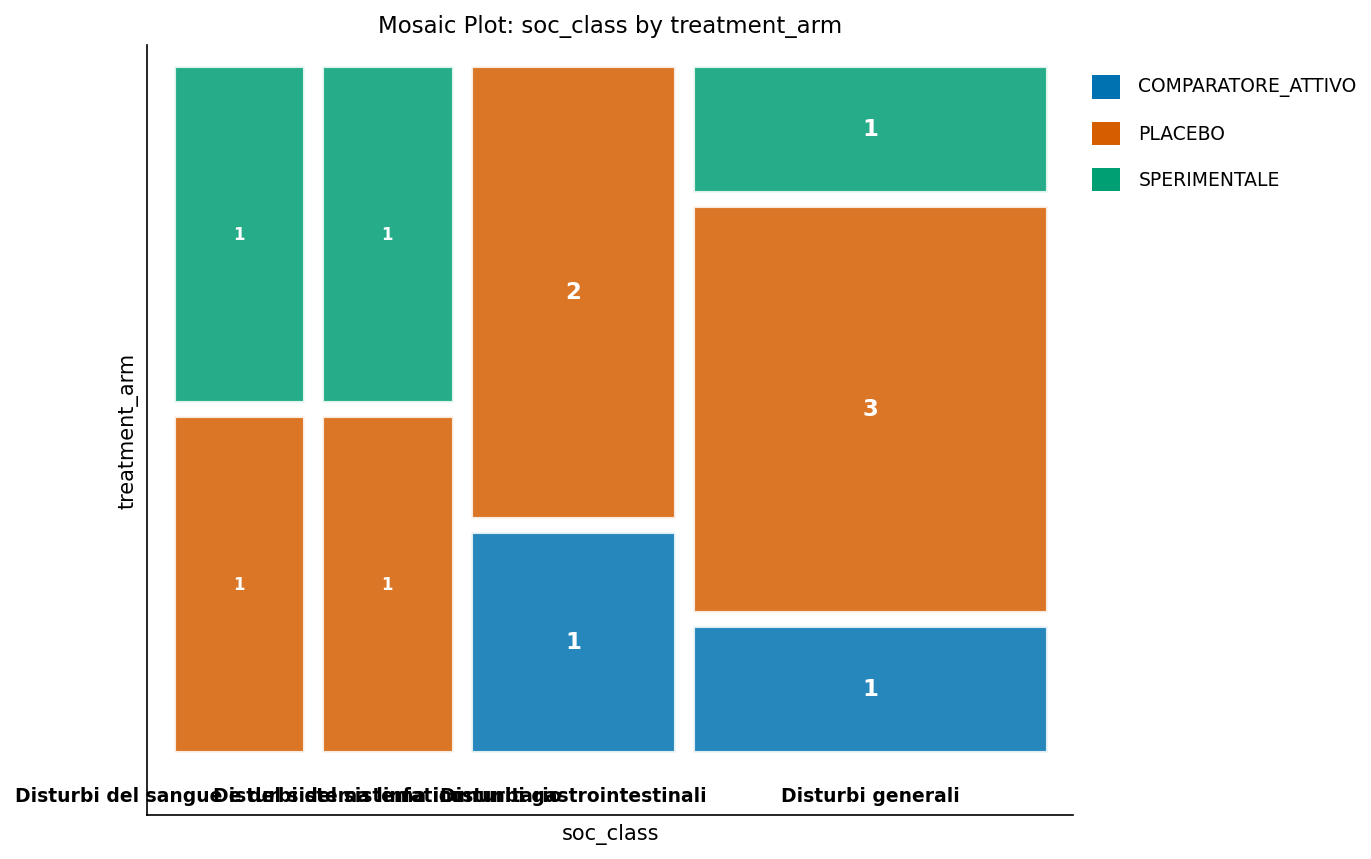

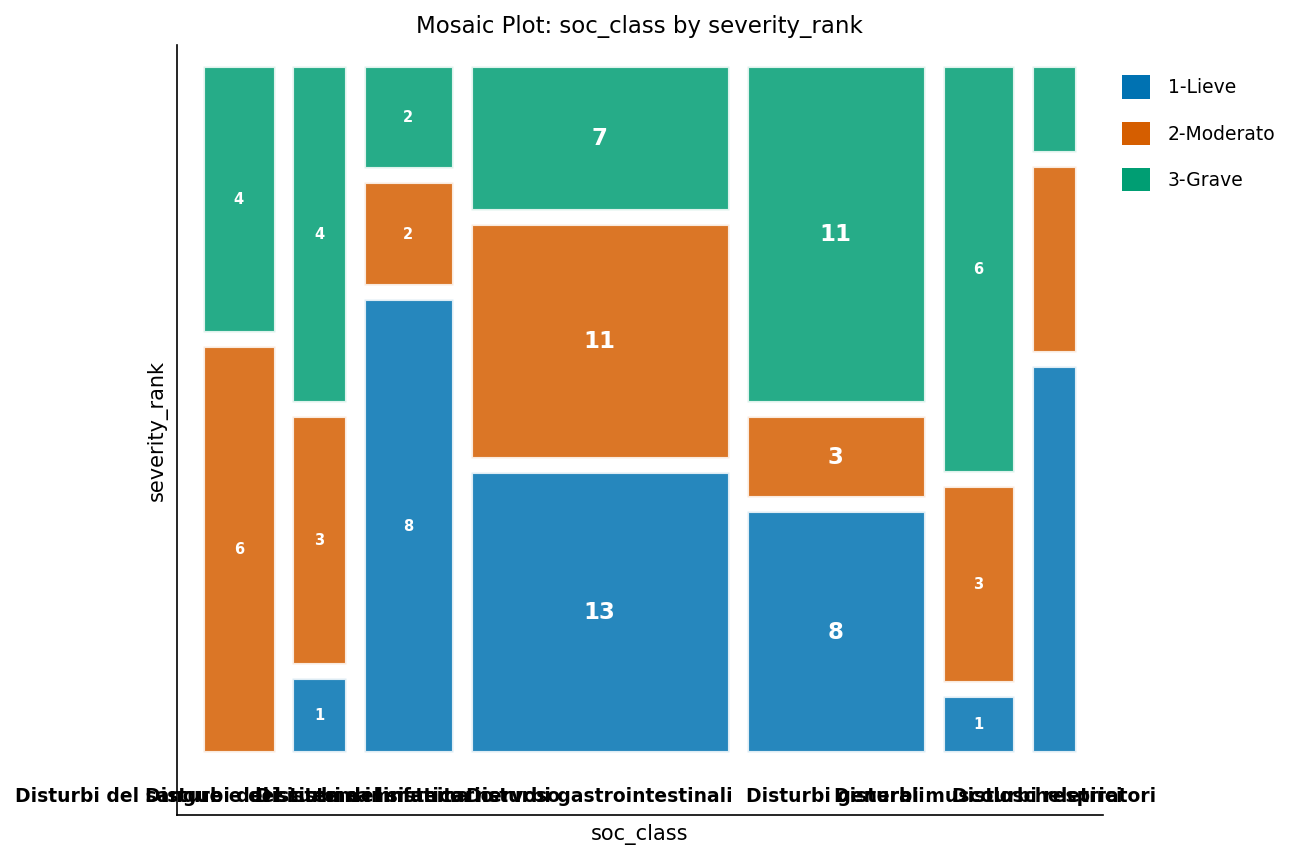

In [7]:
/* --------------------------------------------------------
   Frequenza a livello SOC per braccio di trattamento
   ODS OUTPUT cattura i risultati per il rilevamento dei segnali
   -------------------------------------------------------- */
ODS USCITA onewayfreqs=work.soc_freq_table;

PROCEDURA FREQUENZE DATI=work.ae_coded ORDER=FREQUENZE;
    ETICHETTA soc_class="Classe di Sistema d'Organo"
          treatment_arm="Braccio di Trattamento"
          severity_rank="Gravità";
    TABLES soc_class * treatment_arm / nocol nopercent;
    TABLES soc_class * severity_rank / nocol nopercent;
    TITOLO 'Incidenza EA per Classe di Sistema-Organo e Braccio di Trattamento';
ESEGUIRE;

ODS USCITA CLOSE;


                                  Eventi Avversi Seri per SOC e Braccio di Trattamento                                  

                                                   The FREQ Procedure

Table of Classe di Sistema d'Organo by Braccio di Trattamento

Classe di Sistema d'Organo       |COMPARATORE_ATTIVO |           PLACEBO |      SPERIMENTALE |              Total
---------------------------------+-------------------+-------------------+-------------------+-------------------
Disturbi del sistema immunitario |                 0 |                 1 |                 0 |                  1
---------------------------------+-------------------+-------------------+-------------------+-------------------
Disturbi generali                |                 1 |                 1 |                 1 |                  3
---------------------------------+-------------------+-------------------+-------------------+-------------------
Total                            |                 1 |      


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_soc_class_treatment_arm.spec.json
NOTE: PROC FREQ statement used.


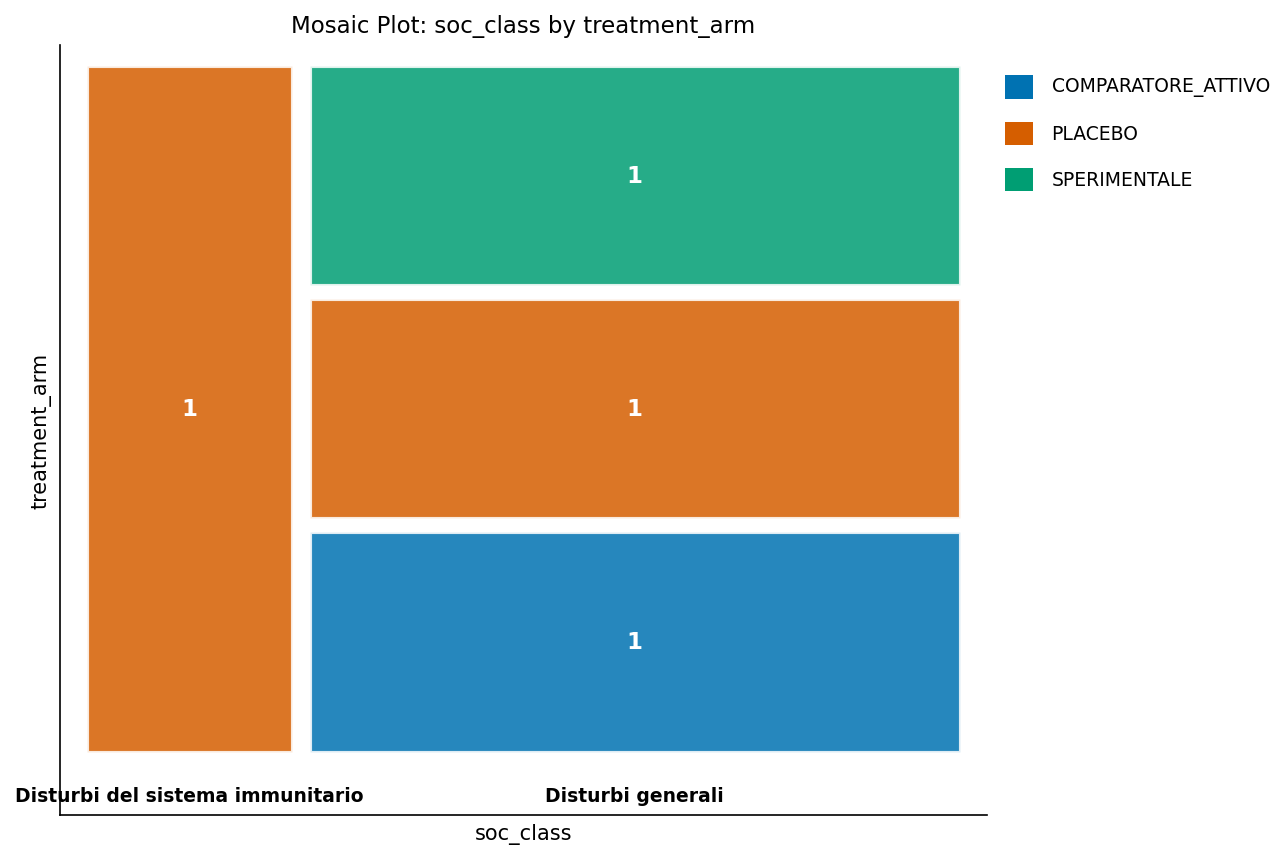

In [8]:
/* --------------------------------------------------------
   Riepilogo degli eventi avversi seri per SOC per la narrativa
   di sicurezza
   -------------------------------------------------------- */
PROCEDURA FREQUENZE DATI=work.ae_coded;
    DOVE aeser = 'Y';
    ETICHETTA soc_class="Classe di Sistema d'Organo"
          treatment_arm="Braccio di Trattamento";
    TABLES soc_class * treatment_arm / nocol nopercent;
    TITOLO 'Eventi Avversi Seri per SOC e Braccio di Trattamento';
ESEGUIRE;


---

### Interpretazione

Un unico formato valore `$pt_to_soc` ha codificato tutti i 100 eventi
avversi a partire da 12 termini preferiti MedDRA testuali in 7 Classi di
Sistema-Organo, e quell'unico formato ha guidato ogni tabella sottostante
senza dover ricodificare i dati.

Per SOC e gravità, **Disturbi gastrointestinali** è la classe più
frequente con 31 dei 100 eventi (13 lievi, 11 moderati, 7 gravi), seguita
da **Disturbi generali** con 22 eventi. Le classi restanti sono più
piccole: Disturbi del sistema nervoso (12), Disturbi del sangue e del
sistema linfatico (10), Disturbi muscoloscheletrici (10), Disturbi del
sistema immunitario (8) e Disturbi respiratori (7). Su tutti gli eventi la
ripartizione per gravità è 35 lievi, 30 moderati e 35 gravi.

Solo 4 eventi sono stati segnalati come seri (`aeser='Y'`): 3 in Disturbi
generali (uno per braccio) e 1 in Disturbi del sistema immunitario
(placebo). La tabulazione incrociata SOC per braccio di trattamento è
costruita sui 12 eventi il cui soggetto corrispondeva a un record di
randomizzazione, quindi i conteggi per braccio sono illustrativi e non
calibrati per un confronto tra bracci.

Il messaggio chiave è il meccanismo FORMAT, non i numeri sintetici: poiché
la mappatura da termine preferito a SOC risiede interamente in PROC
FORMAT, la stessa chiamata `PUT(aedecod, $pt_to_soc.)` ricodifica l'intero
dataset, e l'aggiornamento a una nuova versione del dizionario MedDRA
significa modificare un solo formato anziché ogni report. ODS OUTPUT ha
catturato le frequenze SOC come `work.soc_freq_table` per la revisione dei
segnali a valle.


---

In [9]:
/* --------------------------------------------------------
   Esporta il dataset EA codificato per SOC per la revisione dei
   segnali di sicurezza. L'unico formato $pt_to_soc ha popolato
   soc_class, quindi il file esportato e' pronto per l'analisi
   downstream a livello SOC.
   -------------------------------------------------------- */
PROCEDURA EXPORT DATI=work.ae_coded
    OUTFILE='ae_soc_coded.csv'
    DBMS=csv REPLACE;
ESEGUIRE;



NOTE: PROC EXPORT data=work.ae_coded outfile=ae_soc_coded.csv

NOTE: Exported 100 rows to ae_soc_coded.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Riservato
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Realizzato con <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>